In [258]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(1,'/Users/junesong/programming/GP/GPy')
import GPy
import scipy


In [455]:
dat1 = pd.read_csv("/Users/junesong/Downloads/dat1.csv")
dat2 = pd.read_csv("/Users/junesong/Downloads/dat2.csv")


In [548]:
x_train = dat1['methylCollaspe']
y_train = dat1['rna']
x_train = x_train.to_numpy().reshape(-1, 1)
y_train = y_train.to_numpy().reshape(-1, 1)

x_test = dat2['methylCollaspe']
y_test = dat2['rna']
x_test = x_test.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)


In [549]:
x_train = 1000*scipy.stats.norm.cdf(x_train,0.6,0.15)
#x_train = 10/x_train
y_train = np.log10(y_train+1)
x_test = 1000*scipy.stats.norm.cdf(x_test,0.6,0.15)
y_test = np.log10(y_test+1)



Name : GP regression
Objective : 839.2469741731234
Number of Parameters : 5
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |                value  |  constraints  |  priors
  sum.Mat32.variance       |  0.04000000000000001  |      +ve      |        
  sum.Mat32.lengthscale    |                  0.2  |      +ve      |        
  sum.rbf.variance         |                  1.0  |      +ve      |        
  sum.rbf.lengthscale      |                  1.0  |      +ve      |        
  Gaussian_noise.variance  |                  1.0  |      +ve      |        


{'dataplot': [<matplotlib.collections.PathCollection at 0x1a30fef400>],
 'gpmean': [[<matplotlib.lines.Line2D at 0x1a30fef320>]],
 'gpconfidence': [<matplotlib.collections.PolyCollection at 0x1a30fef908>]}

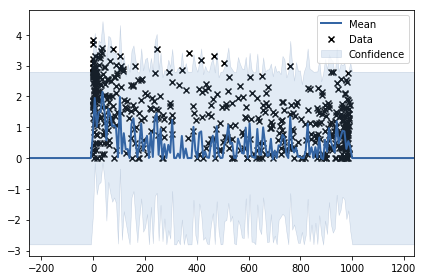

In [550]:
rbf = GPy.kern.RBF(input_dim=1, variance=1.0, lengthscale=1.0)


kernel = GPy.kern.Matern32(1, lengthscale=0.2, variance=0.2**2) 
gpr = GPy.models.GPRegression(x_train, y_train, kernel+rbf)
print(gpr)
gpr.plot()


In [551]:
gpr.optimize(messages=1)




Name : GP regression
Objective : 629.8451313762957
Number of Parameters : 5
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |                  value  |  constraints  |  priors
  sum.Mat32.variance       |  5.722695939102271e-08  |      +ve      |        
  sum.Mat32.lengthscale    |  0.0003868085653099065  |      +ve      |        
  sum.rbf.variance         |      3.521274138966224  |      +ve      |        
  sum.rbf.lengthscale      |     1051.3970383046892  |      +ve      |        
  Gaussian_noise.variance  |     0.6980402165156067  |      +ve      |        


{'dataplot': [<matplotlib.collections.PathCollection at 0x1a31514860>],
 'gpmean': [[<matplotlib.lines.Line2D at 0x1a31514780>]],
 'gpconfidence': [<matplotlib.collections.PolyCollection at 0x1a31514d68>]}

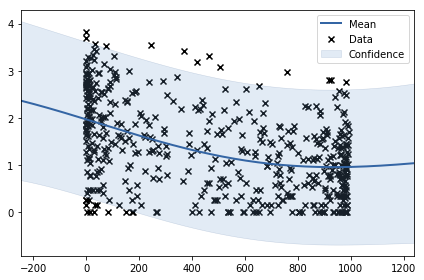

In [552]:
print(gpr)
gpr.plot()

## heatmap 

In [624]:
import seaborn as sns
import matplotlib.pyplot as plt
BetaMatrix = pd.read_csv("/Users/junesong/Downloads/BetaMatrix_average.csv")
RNAMatrix = pd.read_csv("/Users/junesong/Downloads/RNAMatrix_average.csv")

In [625]:
RNAMatrix = RNAMatrix.rename(columns = {"Unnamed: 0":"genes"}) 
RNAMatrix = RNAMatrix.set_index('genes')

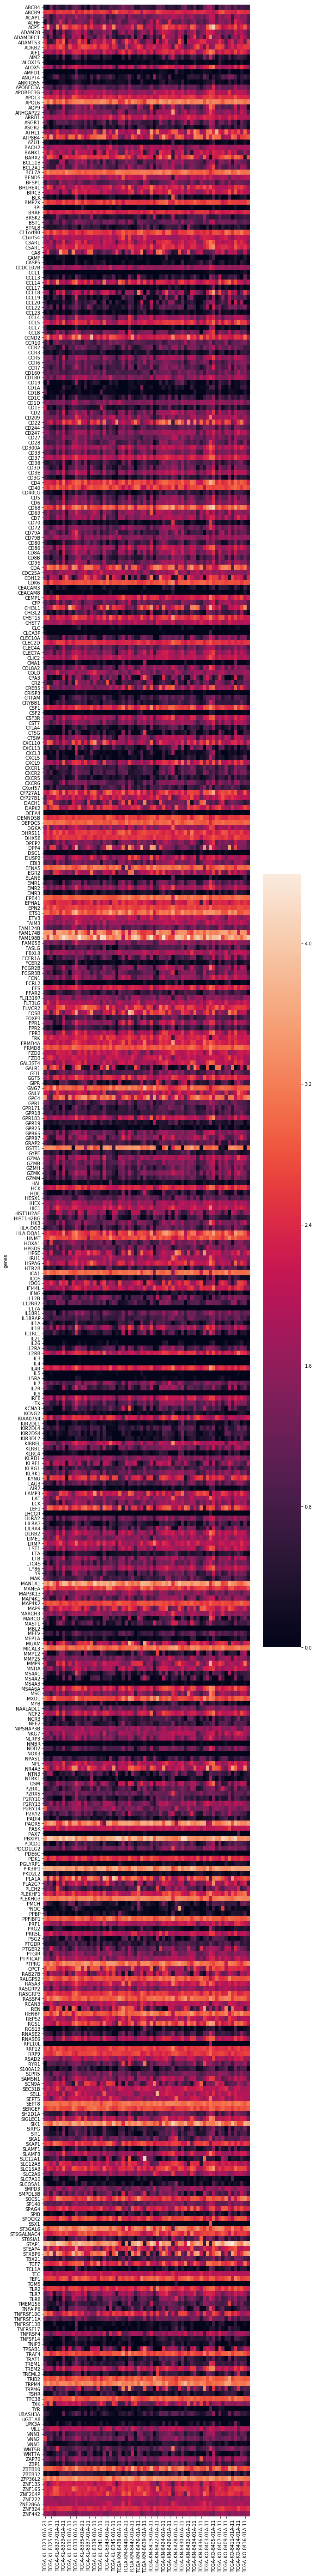

In [635]:
plt.figure(figsize=(10,100))
sns.heatmap(np.log10(RNAMatrix+1))

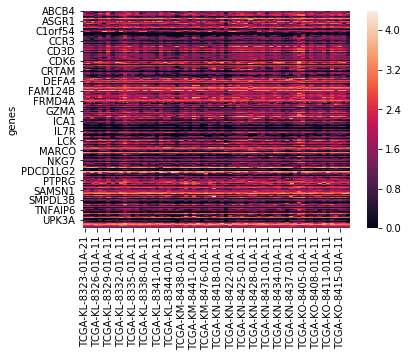

In [632]:
sns.heatmap(np.log10(RNAMatrix+1))

In [603]:
BetaMatrix = BetaMatrix.rename(columns = {"Unnamed: 0":"genes"}) 
BetaMatrix = BetaMatrix.set_index('genes')

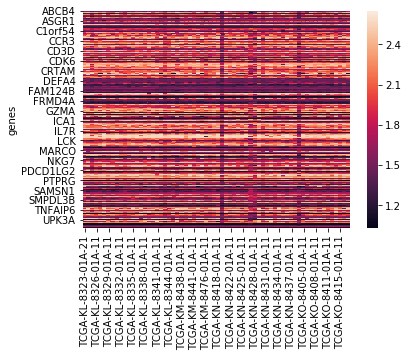

In [605]:
sns.heatmap(np.exp(BetaMatrix))

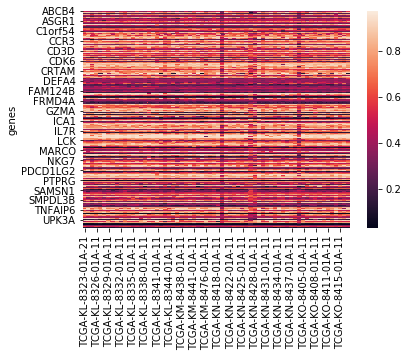

In [622]:
sns.heatmap(BetaMatrix)

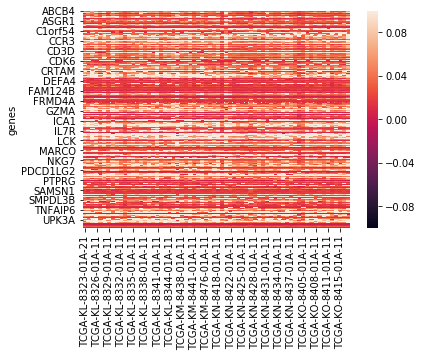

In [618]:
sns.heatmap(np.cor()

In [613]:
BetaMatrix/np.log10(RNAMatrix+1)

,TCGA-KL-8323-01A-21,TCGA-KL-8324-01A-11,TCGA-KL-8325-01A-11,TCGA-KL-8326-01A-11,TCGA-KL-8327-01A-11,TCGA-KL-8328-01A-11,TCGA-KL-8329-01A-11,TCGA-KL-8330-01A-11,TCGA-KL-8331-01A-11,TCGA-KL-8332-01A-11,...,TCGA-KO-8407-01A-11,TCGA-KO-8408-01A-11,TCGA-KO-8409-01A-11,TCGA-KO-8410-01A-11,TCGA-KO-8411-01A-11,TCGA-KO-8413-01A-11,TCGA-KO-8414-01A-11,TCGA-KO-8415-01A-11,TCGA-KO-8416-01A-11,TCGA-KO-8417-01A-11
genes,,,,,,,,,,,,,,,,,,,,,
ABCB4,1.372235,inf,0.252710,1.154177,0.430569,0.608843,1.298479,0.499097,0.715063,0.315431,...,0.350577,0.497668,0.309087,0.311660,0.509624,0.344343,0.768144,0.557823,0.686294,0.473410
ABCB9,0.149380,0.140925,0.132839,0.168586,0.146445,0.138736,0.138158,0.126219,0.141647,0.124683,...,0.133191,0.128805,0.143660,0.151386,0.152487,0.167901,0.144126,0.138004,0.151205,0.142969
ACAP1,0.404907,0.320411,0.663797,0.459578,0.238834,0.387536,0.250453,0.325926,0.228323,0.341100,...,0.193244,0.296722,0.183556,0.214985,0.704134,0.227500,0.214576,0.276345,0.194348,0.617845
ACHE,1.552833,0.288176,0.613609,0.363142,0.252125,0.162203,0.250576,0.358186,0.220817,0.324521,...,0.240791,0.227847,0.293049,0.206495,0.429137,0.139724,0.202128,0.180052,0.249468,0.392436
ACP5,0.255145,0.117885,0.358955,0.586846,0.122239,0.361618,0.168612,0.187675,0.212539,0.214010,...,0.210433,0.284754,0.252907,0.233816,0.168278,0.169751,0.334828,0.220790,0.217520,0.304417
ADAM28,0.906509,0.866710,0.490124,5.054227,0.794372,1.385705,0.394255,0.951295,0.812812,0.449389,...,0.558022,0.721323,0.537336,0.495945,0.648128,0.371767,0.557431,0.378920,0.606609,0.945505
ADAMDEC1,0.579625,3.226560,0.575393,3.094238,1.187869,1.023061,0.383878,1.158376,1.101594,0.480856,...,0.513599,1.611900,0.725404,2.024771,0.626813,0.392919,0.721965,0.422525,0.500378,0.954480
ADAMTS3,0.093686,0.457764,0.442478,0.278153,0.065948,0.099233,0.067000,0.328343,0.120623,0.154500,...,0.070537,0.121830,0.216163,0.113778,0.070163,0.182145,0.138897,0.090856,0.200327,0.086945
ADRB2,0.027341,0.043715,0.027691,0.035932,0.034164,0.034044,0.028427,0.094861,0.019077,0.028938,...,0.024361,0.035055,0.145117,0.055630,0.029404,0.037721,0.026866,0.022953,0.025684,0.027696


In [611]:
np.log10(RNAMatrix+1).head()

,TCGA-KL-8323-01A-21,TCGA-KL-8324-01A-11,TCGA-KL-8325-01A-11,TCGA-KL-8326-01A-11,TCGA-KL-8327-01A-11,TCGA-KL-8328-01A-11,TCGA-KL-8329-01A-11,TCGA-KL-8330-01A-11,TCGA-KL-8331-01A-11,TCGA-KL-8332-01A-11,...,TCGA-KO-8407-01A-11,TCGA-KO-8408-01A-11,TCGA-KO-8409-01A-11,TCGA-KO-8410-01A-11,TCGA-KO-8411-01A-11,TCGA-KO-8413-01A-11,TCGA-KO-8414-01A-11,TCGA-KO-8415-01A-11,TCGA-KO-8416-01A-11,TCGA-KO-8417-01A-11
genes,,,,,,,,,,,,,,,,,,,,,
ABCB4,0.341751,0.000000,1.343009,0.394994,0.823500,0.449077,0.366273,0.837614,0.484456,1.080349,...,1.121990,0.837342,1.210466,1.098363,0.643077,1.084469,0.667836,0.804378,0.670506,0.657161
ABCB9,2.513204,2.628777,2.560641,2.168336,2.507614,2.642614,2.516279,2.540229,2.451478,2.742464,...,2.684692,2.834049,2.438461,2.395841,2.351162,2.239150,2.613460,2.525397,2.402552,2.456603
ACAP1,1.258924,1.436414,0.477526,0.840890,1.665422,1.260498,1.796395,1.177470,1.289150,1.321458,...,1.805940,1.339119,1.729421,1.814261,0.643077,1.767295,1.945921,1.492639,1.634362,0.907530
ACHE,0.254741,1.345307,0.564713,1.036928,1.355990,2.333993,1.502251,0.946482,1.781635,1.150256,...,1.624302,1.546395,1.228606,1.666951,0.771271,2.376144,1.931712,1.847064,1.392255,0.888067
ACP5,2.267838,3.764543,1.630687,1.074681,3.290257,1.777452,3.086914,2.785062,2.225215,2.685133,...,2.594632,1.914854,2.189601,2.483868,2.312872,2.826537,2.024282,2.376521,2.873027,1.706967


In [612]:
BetaMatrix.head()

,TCGA-KL-8323-01A-21,TCGA-KL-8324-01A-11,TCGA-KL-8325-01A-11,TCGA-KL-8326-01A-11,TCGA-KL-8327-01A-11,TCGA-KL-8328-01A-11,TCGA-KL-8329-01A-11,TCGA-KL-8330-01A-11,TCGA-KL-8331-01A-11,TCGA-KL-8332-01A-11,...,TCGA-KO-8407-01A-11,TCGA-KO-8408-01A-11,TCGA-KO-8409-01A-11,TCGA-KO-8410-01A-11,TCGA-KO-8411-01A-11,TCGA-KO-8413-01A-11,TCGA-KO-8414-01A-11,TCGA-KO-8415-01A-11,TCGA-KO-8416-01A-11,TCGA-KO-8417-01A-11
genes,,,,,,,,,,,,,,,,,,,,,
ABCB4,0.468963,0.360568,0.339391,0.455893,0.354574,0.273417,0.475599,0.418050,0.346417,0.340776,...,0.393344,0.416719,0.374139,0.342315,0.327728,0.373429,0.512994,0.448701,0.460164,0.311106
ABCB9,0.375423,0.370461,0.340154,0.365551,0.367226,0.366625,0.347644,0.320624,0.347244,0.341939,...,0.357576,0.365040,0.350309,0.362696,0.358522,0.375955,0.376668,0.348516,0.363278,0.351218
ACAP1,0.509747,0.460243,0.316981,0.386455,0.397759,0.488489,0.449913,0.383768,0.294343,0.450749,...,0.348986,0.397346,0.317445,0.390039,0.452813,0.402059,0.417548,0.412483,0.317635,0.560713
ACHE,0.395571,0.387685,0.346513,0.376553,0.341878,0.378580,0.376428,0.339017,0.393415,0.373282,...,0.391117,0.352341,0.360041,0.344217,0.330981,0.332004,0.390452,0.332567,0.347324,0.348509
ACP5,0.578628,0.443784,0.585343,0.630672,0.402199,0.642760,0.520490,0.522687,0.472944,0.574644,...,0.545997,0.545262,0.553766,0.580769,0.389205,0.479808,0.677786,0.524713,0.624941,0.519629
